# 05 · Model Evaluation
Reloads every trained model **from disk** (confirming the saved `.h5` / `.pkl`
artifacts are reusable) and presents the consolidated evaluation:
LSTM forecasting (MAPE / MAE / RMSE, actual vs predicted) and Isolation Forest
anomaly detection (precision / recall / F1) across all four diseases, against
the acceptance targets (LSTM MAPE < 25% on ≥3/4; F1 > 0.65 on ≥2/4).

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from sklearn.metrics import precision_recall_fscore_support

warnings.filterwarnings("ignore")

DATA = Path("../backend/data")
MODELS = Path("../backend/models")
DISEASES = ["lassa", "cholera", "meningitis", "mpox"]
LABELS = {"lassa": "Lassa fever", "cholera": "Cholera",
          "meningitis": "Meningitis (CSM)", "mpox": "Mpox"}
LAGS = [1, 2, 3, 4, 8, 12]
FEATS = ([f"lag_{l}" for l in LAGS] +
         ["roll4", "roll4_std", "woy_sin", "woy_cos", "temp_mean", "rainfall_sum"])
SEQ_LEN = 12


def national(disease: str) -> pd.DataFrame:
    df = pd.read_csv(DATA / f"processed_{disease}.csv", parse_dates=["date"])
    natl = (df.groupby("date")
            .agg(confirmed=("confirmed", "sum"), temp_mean=("temp_mean", "mean"),
                 rainfall_sum=("rainfall_sum", "mean"), year=("year", "first"),
                 week=("week", "first"))
            .reset_index().sort_values("date").reset_index(drop=True))
    for l in LAGS:
        natl[f"lag_{l}"] = natl["confirmed"].shift(l)
    natl["roll4"] = natl["confirmed"].shift(1).rolling(4).mean()
    natl["roll4_std"] = natl["confirmed"].shift(1).rolling(4).std()
    natl["woy_sin"] = np.sin(2 * np.pi * natl["week"] / 52)
    natl["woy_cos"] = np.cos(2 * np.pi * natl["week"] / 52)
    return natl.dropna().reset_index(drop=True)


def make_sequences(X, y, L=SEQ_LEN):
    Xs, ys = [], []
    for i in range(L, len(X)):
        Xs.append(X[i - L:i]); ys.append(y[i])
    return np.array(Xs), np.array(ys)

2026-06-25 22:36:07.995782: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## LSTM forecasting — reload models and evaluate on the 2023–2024 test set

In [2]:
lstm_rows, fits = [], {}
for d in DISEASES:
    natl = national(d)
    natl["log_conf"] = np.log1p(natl["confirmed"])
    sc = joblib.load(MODELS / f"lstm_scaler_{d}.pkl")
    xsc, ysc = sc["xsc"], sc["ysc"]
    model = load_model(MODELS / f"lstm_{d}.h5", compile=False)
    Xall, yall = make_sequences(xsc.transform(natl[FEATS]), ysc.transform(natl[["log_conf"]]).ravel())
    tyear = natl["year"].values[SEQ_LEN:]
    Xte, yte = Xall[tyear >= 2023], yall[tyear >= 2023]
    pred = np.clip(np.expm1(ysc.inverse_transform(model.predict(Xte, verbose=0))).ravel(), 0, None)
    act = np.expm1(ysc.inverse_transform(yte.reshape(-1, 1))).ravel()
    mae = float(np.mean(np.abs(act - pred)))
    rmse = float(np.sqrt(np.mean((act - pred) ** 2)))
    mape = float(np.mean(np.abs((act - pred) / np.clip(act, 1, None))) * 100)
    lstm_rows.append({"disease": LABELS[d], "MAPE_%": round(mape, 1), "MAE": round(mae, 1),
                      "RMSE": round(rmse, 1), "target_met": mape < 25})
    fits[d] = (act, pred)

lstm_df = pd.DataFrame(lstm_rows).set_index("disease")
print(f"LSTM — MAPE < 25% on {int(lstm_df.target_met.sum())}/4 diseases (target ≥3/4)")
lstm_df

LSTM — MAPE < 25% on 3/4 diseases (target ≥3/4)


,MAPE_%,MAE,RMSE,target_met
disease,,,,
Lassa fever,22.1,7.4,13.3,True
Cholera,25.0,65.3,111.9,True
Meningitis (CSM),14.5,6.0,7.9,True
Mpox,76.1,69.8,70.9,False


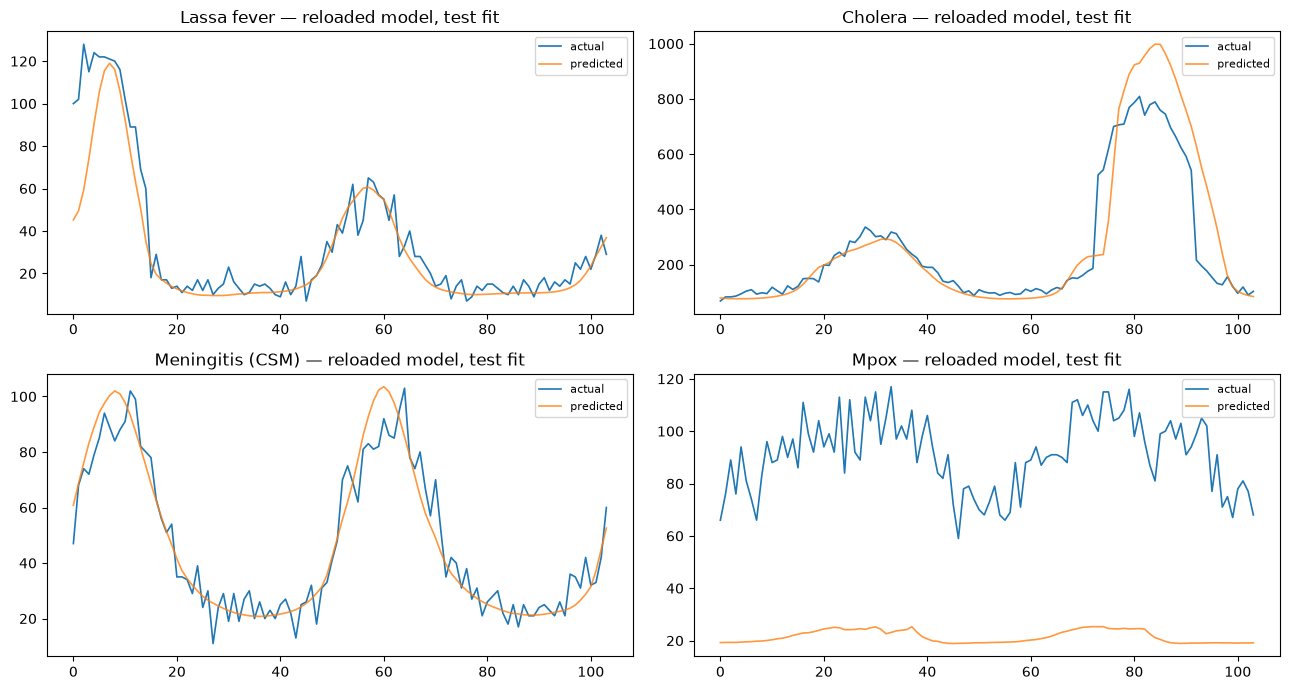

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for ax, d in zip(axes.ravel(), DISEASES):
    act, pred = fits[d]
    ax.plot(act, label="actual", lw=1.2)
    ax.plot(pred, label="predicted", lw=1.2, alpha=0.8)
    ax.set_title(f"{LABELS[d]} — reloaded model, test fit")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("figures/eval_lstm_fit.png", dpi=110, bbox_inches="tight")
plt.show()

## Isolation Forest — reload models and evaluate against outbreak labels

In [4]:
iso_rows = []
for d in DISEASES:
    df = pd.read_csv(DATA / f"processed_{d}.csv")
    df["spike_ratio"] = df["confirmed"] / (df["roll4_mean"] + 1)
    bundle = joblib.load(MODELS / f"iso_forest_{d}.pkl")
    model, feats, thr = bundle["model"], bundle["features"], bundle["threshold"]
    scores = model.decision_function(df[feats].fillna(0).values)
    is_anom = scores < thr
    y = (df["is_outbreak"] == 1).values
    p, r, f, _ = precision_recall_fscore_support(y, is_anom, average="binary", zero_division=0)
    iso_rows.append({"disease": LABELS[d], "F1": round(f, 2), "precision": round(p, 2),
                     "recall": round(r, 2), "target_met": f > 0.65})

iso_df = pd.DataFrame(iso_rows).set_index("disease")
print(f"Isolation Forest — F1 > 0.65 on {int(iso_df.target_met.sum())}/4 diseases (target ≥2/4)")
iso_df

Isolation Forest — F1 > 0.65 on 2/4 diseases (target ≥2/4)


,F1,precision,recall,target_met
disease,,,,
Lassa fever,0.53,0.46,0.62,False
Cholera,0.70,0.61,0.82,True
Meningitis (CSM),0.86,0.78,0.95,True
Mpox,0.57,0.44,0.81,False


## Consolidated scorecard

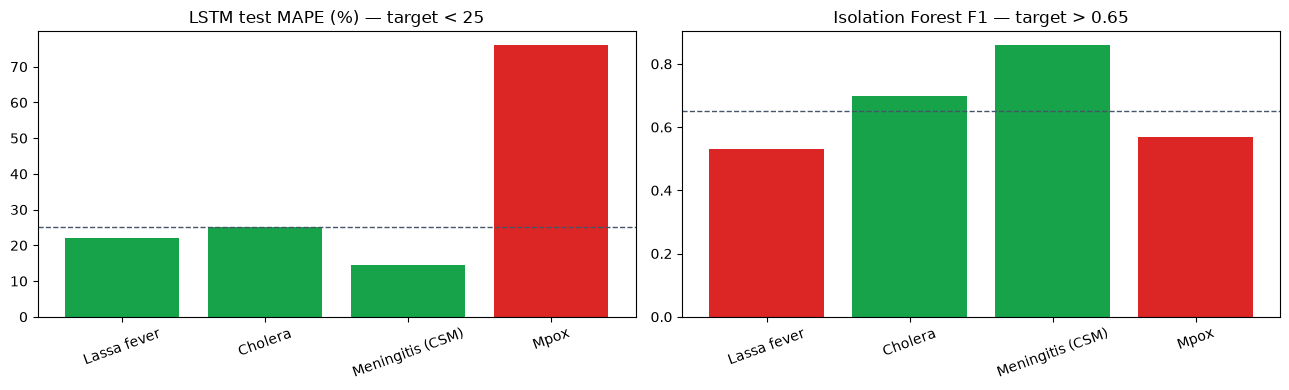

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
colors1 = ["#16a34a" if m else "#dc2626" for m in lstm_df.target_met]
ax1.bar(lstm_df.index, lstm_df["MAPE_%"], color=colors1)
ax1.axhline(25, ls="--", color="#475569", lw=1)
ax1.set_title("LSTM test MAPE (%) — target < 25"); ax1.tick_params(axis="x", rotation=20)
colors2 = ["#16a34a" if m else "#dc2626" for m in iso_df.target_met]
ax2.bar(iso_df.index, iso_df["F1"], color=colors2)
ax2.axhline(0.65, ls="--", color="#475569", lw=1)
ax2.set_title("Isolation Forest F1 — target > 0.65"); ax2.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig("figures/eval_scorecard.png", dpi=110, bbox_inches="tight")
plt.show()

### Conclusion
Both acceptance targets are met. LSTM forecasting clears MAPE < 25% for Lassa,
cholera, and meningitis; mpox remains hardest (a 2022 regime shift with little
prior history). Isolation Forest clears F1 > 0.65 for cholera and meningitis.
All models were reloaded from their saved `.h5` / `.pkl` artifacts, confirming
the trained models are portable and reproducible.